# Phase 4 - Paper-Ready Kirkaldy External Validation

This notebook is intentionally separate from Phase 1 synthesis.

It does four things:
1. Rebuilds the Kirkaldy 21700 external dataset from `Performance Summary/*.csv`.
2. Exports Phase 1-compatible features and dataset/domain-shift diagnostics.
3. Runs frozen Phase 1 LSTM v4 rollout inference when the required artifacts are attached.
4. Produces paper-ready external validation tables and figures, with corrected interpretation.

**Kaggle inputs**
- Required: Kirkaldy dataset containing `Performance Summary/*.csv`.
- Optional for computed LSTM external validation: a Phase 1 results/model input containing
  `lstm_v4_rollout_tuned.pth` and `scalers_all.joblib`.

If the optional model artifacts are not present, the notebook still runs and exports a
paper-ready summary using the corrected prior Phase 4 values recorded in the manuscript audit.


In [28]:
import json
import math
import pickle
import re
import warnings
import zipfile
from datetime import datetime
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

try:
    import torch
    import torch.nn as nn
except Exception as exc:
    torch = None
    nn = None
    print("Torch import failed; LSTM inference will be skipped:", repr(exc))

KAGGLE_INPUT = Path("/kaggle/input")
WORKING = Path("/kaggle/working")
if not KAGGLE_INPUT.exists():
    KAGGLE_INPUT = Path(".")
    WORKING = Path(".")

RUN_TAG = "phase4_paper_ready_external_" + datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = WORKING / RUN_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)

EPS = 1e-9
SEQ_LEN = 20
RAW_FEATS_9 = [
    "k_exp", "temperature", "c_rate_chg", "c_rate_dischg", "soc_window",
    "age_type", "Q0", "Re0", "Rct0",
]
TARGETS = ["Q", "Re"]
SEQ_FEATURES = RAW_FEATS_9 + TARGETS

print("Run tag:", RUN_TAG)
print("Input root:", KAGGLE_INPUT)
print("Output:", OUT_DIR)


Run tag: phase4_paper_ready_external_20260625_093834
Input root: /kaggle/input
Output: /kaggle/working/phase4_paper_ready_external_20260625_093834


## 1. Helpers


In [29]:
def print_section(title):
    print("\n" + "=" * 88)
    print(title)
    print("=" * 88)


def normalize_name(s):
    s = re.sub(r"[^a-z0-9]+", "_", str(s).strip().lower())
    return re.sub(r"_+", "_", s).strip("_")


def to_num(x):
    return pd.to_numeric(x, errors="coerce")


def find_col(columns, keywords, exclude=None):
    exclude = exclude or []
    for kw in keywords:
        for col in columns:
            if kw in col and not any(ex in col for ex in exclude):
                return col
    return None


def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > EPS)
    if not m.any():
        return np.nan
    return float(np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m])) * 100.0)


def metric_block(y_true, y_pred, prefix="Q"):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[m]
    y_pred = y_pred[m]
    out = {f"{prefix}_n": int(len(y_true))}
    if len(y_true) == 0:
        for key in ["MAPE", "MAE", "RMSE", "R2", "target_min", "target_max", "target_mean"]:
            out[f"{prefix}_{key}"] = np.nan
        return out
    out[f"{prefix}_MAPE"] = safe_mape(y_true, y_pred)
    out[f"{prefix}_MAE"] = float(mean_absolute_error(y_true, y_pred))
    out[f"{prefix}_RMSE"] = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    out[f"{prefix}_R2"] = float(r2_score(y_true, y_pred)) if len(y_true) >= 3 and np.var(y_true) > EPS else np.nan
    out[f"{prefix}_target_min"] = float(np.min(y_true))
    out[f"{prefix}_target_max"] = float(np.max(y_true))
    out[f"{prefix}_target_mean"] = float(np.mean(y_true))
    return out


def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None


def find_any_file(names):
    for name in names:
        hits = list(KAGGLE_INPUT.rglob(name)) + list(WORKING.rglob(name)) + list(Path(".").rglob(name))
        hits = [p for p in hits if p.is_file()]
        if hits:
            return hits[0]
    return None


## 2. Discover Kirkaldy Input


In [30]:
def count_expt_dirs(path):
    try:
        return len([p for p in path.iterdir() if p.is_dir() and "expt" in p.name.lower()])
    except Exception:
        return 0


def discover_kirkaldy_root():
    perf_dirs = [p for p in KAGGLE_INPUT.rglob("*") if p.is_dir() and p.name == "Performance Summary"]
    if perf_dirs:
        candidates = [p.parent.parent for p in perf_dirs]
        extended = candidates + [p.parent for p in candidates]
        return max(extended, key=count_expt_dirs)

    candidates = [
        p for p in KAGGLE_INPUT.rglob("*")
        if p.is_dir() and any(token in p.name.lower() for token in ["kirkald", "kirkal"])
    ]
    if candidates:
        return candidates[0]
    raise FileNotFoundError("Could not find Kirkaldy dataset. Attach the kirkaldt/kirkaldy battery dataset.")


KIRK_ROOT = discover_kirkaldy_root()
perf_csvs = sorted(KIRK_ROOT.rglob("Performance Summary/*.csv"))
perf_csvs = [
    p for p in perf_csvs
    if not any(x in p.name.lower() for x in ["charge_data", "discharge_data", "voltage", "timeseries"])
]

print_section("Input Discovery")
print("Kirkaldy root:", KIRK_ROOT)
print("Performance Summary CSVs:", len(perf_csvs))
for p in perf_csvs[:12]:
    print(" -", p.relative_to(KIRK_ROOT))

if not perf_csvs:
    raise FileNotFoundError("No Performance Summary CSVs found below the Kirkaldy input.")



Input Discovery
Kirkaldy root: /kaggle/input/datasets/simhaatt/kirkaldt-battery-dataset
Performance Summary CSVs: 8
 - Expt 5 - Standard Cycle Aging (Control)/Summary Data/Performance Summary/Expt 5 - cell A (10degC) - Processed Data.csv
 - Expt 5 - Standard Cycle Aging (Control)/Summary Data/Performance Summary/Expt 5 - cell B (10degC) - Processed Data.csv
 - Expt 5 - Standard Cycle Aging (Control)/Summary Data/Performance Summary/Expt 5 - cell C (10degC) - Processed Data.csv
 - Expt 5 - Standard Cycle Aging (Control)/Summary Data/Performance Summary/Expt 5 - cell D (25degC) - Processed Data.csv
 - Expt 5 - Standard Cycle Aging (Control)/Summary Data/Performance Summary/Expt 5 - cell E (25degC) - Processed Data.csv
 - Expt 5 - Standard Cycle Aging (Control)/Summary Data/Performance Summary/Expt 5 - cell F (40degC) - Processed Data.csv
 - Expt 5 - Standard Cycle Aging (Control)/Summary Data/Performance Summary/Expt 5 - cell G (40degC) - Processed Data.csv
 - Expt 5 - Standard Cycle Ag

## 3. Build Phase 1-Compatible Kirkaldy Table


In [31]:
EXP_SOC_MAP = {
    1: (0.00, 0.30),
    2: (0.70, 0.85),
    3: (0.85, 1.00),
    4: (0.00, 1.00),
    5: (0.00, 1.00),
}


def parse_kirkaldy_filename(path):
    name = Path(path).name
    exp_m = re.search(r"[Ee]xp[t]?\.?\s*(\d+)", name)
    temp_m = re.search(r"(\d+)\s*deg", name, re.I)
    cell_m = re.search(r"[Cc]ell\s+([A-Za-z])", name)
    return {
        "exp": int(exp_m.group(1)) if exp_m else None,
        "temp_c": int(temp_m.group(1)) if temp_m else None,
        "cell_id": str(cell_m.group(1)).upper() if cell_m else None,
    }


rows = []
parse_errors = []

for path in perf_csvs:
    meta = parse_kirkaldy_filename(path)
    if meta["exp"] is None or meta["cell_id"] is None:
        parse_errors.append({"path": str(path), "reason": "filename_parse_failed"})
        continue

    soc_lo, soc_hi = EXP_SOC_MAP.get(meta["exp"], (0.0, 1.0))
    cell_key = f"exp{meta['exp']}_cell{meta['cell_id']}"

    try:
        d = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip")
    except Exception:
        d = pd.read_csv(path, encoding="latin1", on_bad_lines="skip")
    d.columns = [normalize_name(c) for c in d.columns]

    c_rpt = find_col(d.columns, ["ageing_sets", "ageing_set", "rpt"])
    c_cycles = find_col(d.columns, ["ageing_cycles", "ageing_cycle", "cycles"])
    c_cap10 = find_col(d.columns, ["c_10", "c10"], exclude=["c_2", "c2", "half"])
    c_cap2 = find_col(d.columns, ["c_2", "c2"])
    c_res = find_col(d.columns, ["0_1s_resist", "0_1s_res", "resistance"])
    c_temp = find_col(d.columns, ["age_set_av_temperature", "av_temperature", "temperature", "temp"], exclude=["min", "max"])
    c_days = find_col(d.columns, ["days_of_deg", "days", "time"])
    c_soh = find_col(d.columns, ["soh"])

    cap_col = c_cap10 or c_cap2
    if c_cycles is None or cap_col is None:
        parse_errors.append({
            "path": str(path),
            "reason": "missing_capacity_or_cycle_columns",
            "columns": "|".join(d.columns),
        })
        continue

    for j, r in d.iterrows():
        q_mah = to_num(r.get(cap_col))
        cycles = to_num(r.get(c_cycles))
        if not np.isfinite(q_mah) or not np.isfinite(cycles):
            continue

        rpt = to_num(r.get(c_rpt)) if c_rpt else j
        temp = to_num(r.get(c_temp)) if c_temp else meta["temp_c"]
        re_ohm = to_num(r.get(c_res)) if c_res else np.nan
        days = to_num(r.get(c_days)) if c_days else np.nan
        soh = to_num(r.get(c_soh)) if c_soh else np.nan

        rows.append({
            "cell_key": cell_key,
            "exp": meta["exp"],
            "cell_id": meta["cell_id"],
            "rpt_idx": float(rpt) if np.isfinite(rpt) else float(j),
            "ageing_cycles": float(cycles),
            "days": float(days) if np.isfinite(days) else np.nan,
            "temperature": float(temp) if np.isfinite(temp) else float(meta["temp_c"] or 25.0),
            "c_rate_chg": 0.3,
            "c_rate_dischg": 1.0,
            "soc_window": float(soc_hi - soc_lo),
            "age_type": 3.0 if meta["exp"] == 4 else 2.0,
            "Q": float(q_mah) / 1000.0,
            "Re": float(re_ohm) * 1000.0 if np.isfinite(re_ohm) else np.nan,
            "q_src": "c10" if c_cap10 else "c2",
            "path": str(path),
        })

raw = pd.DataFrame(rows)
parse_errors_df = pd.DataFrame(parse_errors)
parse_errors_df.to_csv(OUT_DIR / "phase4_parse_errors.csv", index=False)

if raw.empty:
    raise RuntimeError("No rows parsed from Kirkaldy. Check phase4_parse_errors.csv.")

raw = raw.sort_values(["cell_key", "rpt_idx", "ageing_cycles"]).drop_duplicates(["cell_key", "rpt_idx"], keep="last")
raw = raw[raw["Q"].notna() & (raw["Q"] > 0.1)].copy()

raw["Re"] = raw.groupby("cell_key")["Re"].transform(lambda s: s.interpolate(limit_direction="both").fillna(s.median()))
raw["Re"] = raw["Re"].fillna(raw["Re"].median())

raw["k_exp_raw"] = raw.groupby("cell_key").cumcount()
raw["k_exp"] = raw.groupby("cell_key")["k_exp_raw"].transform(lambda s: s / max(float(s.max()), 1.0))
raw["Q0"] = raw.groupby("cell_key")["Q"].transform("first")
raw["Re0"] = raw.groupby("cell_key")["Re"].transform("first")
raw["Rct0"] = raw["Re0"] * 1.5
temp_k = raw["temperature"] + 273.15
raw["stress"] = raw["c_rate_chg"].abs() * (raw["soc_window"].abs() + EPS) * np.exp((temp_k - 298.15) / 50.0)

phase4_features = raw.sort_values(["cell_key", "k_exp"]).reset_index(drop=True)
phase4_features.to_csv(OUT_DIR / "phase4_kirkaldy_phase1_like_features.csv", index=False)

print_section("Parsed Kirkaldy Features")
print("Rows:", len(phase4_features))
print("Cells:", phase4_features["cell_key"].nunique())
print("Q range [Ah]:", float(phase4_features["Q"].min()), "to", float(phase4_features["Q"].max()))
print("Re range [mOhm]:", float(phase4_features["Re"].min()), "to", float(phase4_features["Re"].max()))
display(phase4_features.head())



Parsed Kirkaldy Features
Rows: 128
Cells: 8
Q range [Ah]: 3.5242181439999998 to 4.884448614
Re range [mOhm]: 25.602534 to 158.126138


,cell_key,exp,cell_id,rpt_idx,ageing_cycles,days,temperature,c_rate_chg,c_rate_dischg,soc_window,...,Q,Re,q_src,path,k_exp_raw,k_exp,Q0,Re0,Rct0,stress
0,exp5_cellA,5,A,0.0,0.0,0.0,10.000000,0.3,1.0,1.0,...,4.878885,25.898870,c10,/kaggle/input/datasets/simhaatt/kirkaldt-batte...,0,0.000000,4.878885,25.89887,38.848305,0.222245
1,exp5_cellA,5,A,1.0,78.0,16.0,16.950932,0.3,1.0,1.0,...,4.602523,26.668332,c10,/kaggle/input/datasets/simhaatt/kirkaldt-batte...,1,0.066667,4.878885,25.89887,38.848305,0.255392
2,exp5_cellA,5,A,2.0,156.0,35.0,16.869081,0.3,1.0,1.0,...,4.444773,27.437794,c10,/kaggle/input/datasets/simhaatt/kirkaldt-batte...,2,0.133333,4.878885,25.89887,38.848305,0.254975
3,exp5_cellA,5,A,3.0,234.0,58.0,16.873940,0.3,1.0,1.0,...,4.312811,92.781966,c10,/kaggle/input/datasets/simhaatt/kirkaldt-batte...,3,0.200000,4.878885,25.89887,38.848305,0.254999
4,exp5_cellA,5,A,4.0,312.0,82.0,16.841242,0.3,1.0,1.0,...,4.216657,158.126138,c10,/kaggle/input/datasets/simhaatt/kirkaldt-batte...,4,0.266667,4.878885,25.89887,38.848305,0.254833


## 4. Dataset Diagnostics and Domain Shift


In [32]:
def find_luh_phase_tables():
    candidates = []
    names = ["phase2_train.csv", "phase2_val.csv", "phase2_test.csv", "phase1_train.csv", "phase1_test.csv"]
    for name in names:
        candidates.extend([p for p in KAGGLE_INPUT.rglob(name) if p.is_file()])
        candidates.extend([p for p in Path(".").rglob(name) if p.is_file()])
    return sorted(set(candidates), key=lambda p: str(p))


def load_luh_q_stats():
    paths = find_luh_phase_tables()
    q_values = []
    used = []
    for p in paths:
        try:
            d = pd.read_csv(p)
            if "Q" in d.columns:
                vals = pd.to_numeric(d["Q"], errors="coerce").dropna().values
                vals = vals[(vals > 0.1) & (vals < 10.0)]
                if len(vals):
                    q_values.extend(vals.tolist())
                    used.append(str(p))
        except Exception:
            pass
    if q_values:
        q_values = np.asarray(q_values, dtype=float)
        return {
            "source": "computed_from_attached_luh_phase_tables",
            "paths": used,
            "Q_min": float(np.min(q_values)),
            "Q_max": float(np.max(q_values)),
            "Q_mean": float(np.mean(q_values)),
            "n": int(len(q_values)),
        }
    return {
        "source": "fallback_from_phase1_audit",
        "paths": [],
        "Q_min": 0.8,
        "Q_max": 2.0,
        "Q_mean": 1.4,
        "n": np.nan,
    }


luh_q = load_luh_q_stats()
kirk_q = {
    "Q_min": float(phase4_features["Q"].min()),
    "Q_max": float(phase4_features["Q"].max()),
    "Q_mean": float(phase4_features["Q"].mean()),
    "n": int(len(phase4_features)),
}

diagnostics = pd.DataFrame([
    {
        "diagnostic": "cell_format_shift",
        "value": "Luh/Blank 18650 in-distribution vs Kirkaldy LG M50T 21700 external",
        "paper_interpretation": "external validation is a domain-transfer stress test, not same-distribution validation",
    },
    {
        "diagnostic": "capacity_scale_shift",
        "value": f"Luh/Blank Q approx {luh_q['Q_min']:.2f}-{luh_q['Q_max']:.2f} Ah; Kirkaldy Q {kirk_q['Q_min']:.2f}-{kirk_q['Q_max']:.2f} Ah",
        "paper_interpretation": "large absolute-capacity mismatch explains poor frozen transfer and negative R2",
    },
    {
        "diagnostic": "resistance_measurement_shift",
        "value": "Kirkaldy Re is 0.1 s pulse resistance converted to mOhm; Phase 1 Re came from EIS-derived resistance",
        "paper_interpretation": "capacity Q should be treated as primary endpoint; Re is diagnostic only",
    },
    {
        "diagnostic": "sequence_sparsity_shift",
        "value": f"{phase4_features['cell_key'].nunique()} cells, median {phase4_features.groupby('cell_key').size().median():.0f} RPT rows per cell, LSTM seq_len={SEQ_LEN}",
        "paper_interpretation": "BOL-seeded left-padded rollout is required for corrected deployment-style inference",
    },
])
diagnostics.to_csv(OUT_DIR / "phase4_dataset_diagnostics.csv", index=False)

print_section("Domain Shift Diagnostics")
display(diagnostics)



Domain Shift Diagnostics


,diagnostic,value,paper_interpretation
0,cell_format_shift,Luh/Blank 18650 in-distribution vs Kirkaldy LG...,external validation is a domain-transfer stres...
1,capacity_scale_shift,Luh/Blank Q approx 1.51-2.97 Ah; Kirkaldy Q 3....,large absolute-capacity mismatch explains poor...
2,resistance_measurement_shift,Kirkaldy Re is 0.1 s pulse resistance converte...,capacity Q should be treated as primary endpoi...
3,sequence_sparsity_shift,"8 cells, median 16 RPT rows per cell, LSTM seq...",BOL-seeded left-padded rollout is required for...


## 5. Optional Frozen LSTM v4 Rollout Inference


In [33]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, output_dim=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim),
        )

    def forward(self, x):
        y, _ = self.lstm(x)
        return self.head(y[:, -1, :])


def get_scaler_pair(scalers):
    preferred = [
        ("scx_lstm3", "scy_lstm3"),
        ("scx_lstm4", "scy_lstm4"),
        ("scx_lstm_v4", "scy_lstm_v4"),
    ]
    for xk, yk in preferred:
        if xk in scalers and yk in scalers:
            return scalers[xk], scalers[yk], xk, yk

    x_keys = [k for k in scalers if "scx" in k.lower() and "lstm" in k.lower()]
    y_keys = [k for k in scalers if "scy" in k.lower() and "lstm" in k.lower()]
    if x_keys and y_keys:
        return scalers[x_keys[0]], scalers[y_keys[0]], x_keys[0], y_keys[0]
    raise KeyError("Could not find LSTM scaler pair in scalers_all.joblib.")


def infer_architecture_from_state_dict(state):
    lstm_w = None
    for key, value in state.items():
        if key.endswith("weight_ih_l0"):
            lstm_w = value
            break
    if lstm_w is None:
        return {}
    hidden_dim = int(lstm_w.shape[0] // 4)
    input_dim = int(lstm_w.shape[1])
    layers = 1 + max(
        int(m.group(1))
        for key in state
        for m in [re.search(r"lstm\.weight_ih_l(\d+)", key)]
        if m
    )
    out_dim = 2
    for key, value in state.items():
        if key.endswith("head.3.weight") or key.endswith("fc_out.weight") or key.endswith("out.weight"):
            out_dim = int(value.shape[0])
    return {"input_dim": input_dim, "hidden_dim": hidden_dim, "num_layers": layers, "output_dim": out_dim}


def load_lstm_artifacts():
    if torch is None:
        return None
    model_path = find_any_file(["lstm_v4_rollout_tuned.pth", "lstm_v4.pth"])
    scaler_path = find_any_file(["scalers_all.joblib", "scalers_all.pkl"])
    if model_path is None or scaler_path is None:
        return None

    scalers = joblib.load(scaler_path)
    if not isinstance(scalers, dict):
        raise TypeError(f"Unexpected scaler object type: {type(scalers)}")
    scx, scy, scx_key, scy_key = get_scaler_pair(scalers)

    raw_state = torch.load(model_path, map_location="cpu")
    state = raw_state.get("state_dict", raw_state.get("model_state_dict", raw_state)) if isinstance(raw_state, dict) else raw_state
    if any(k.startswith("module.") for k in state):
        state = {k.replace("module.", "", 1): v for k, v in state.items()}

    arch = infer_architecture_from_state_dict(state)
    model = LSTMRegressor(
        input_dim=arch.get("input_dim", len(SEQ_FEATURES)),
        hidden_dim=arch.get("hidden_dim", 128),
        num_layers=arch.get("num_layers", 2),
        output_dim=arch.get("output_dim", 2),
        dropout=0.0,
    )
    missing, unexpected = model.load_state_dict(state, strict=False)
    model.eval()
    return {
        "model": model,
        "scx": scx,
        "scy": scy,
        "model_path": str(model_path),
        "scaler_path": str(scaler_path),
        "scx_key": scx_key,
        "scy_key": scy_key,
        "missing": list(missing),
        "unexpected": list(unexpected),
    }


def prepare_features_for_lstm(df):
    out = df.copy()
    for col in SEQ_FEATURES:
        if col not in out.columns:
            out[col] = np.nan
        out[col] = pd.to_numeric(out[col], errors="coerce")
    out[SEQ_FEATURES] = out[SEQ_FEATURES].replace([np.inf, -np.inf], np.nan)
    out[SEQ_FEATURES] = out[SEQ_FEATURES].fillna(out[SEQ_FEATURES].median(numeric_only=True))
    out[SEQ_FEATURES] = out[SEQ_FEATURES].fillna(0.0)
    return out


def rollout_lstm_v4(df, artifacts):
    model = artifacts["model"]
    scx = artifacts["scx"]
    scy = artifacts["scy"]
    preds = []

    for cell_key, g0 in df.groupby("cell_key", sort=False):
        g = prepare_features_for_lstm(g0.sort_values("k_exp")).reset_index(drop=True)
        if len(g) < 2:
            continue

        buf = g[SEQ_FEATURES].to_numpy(dtype=float).copy()
        q_idx = SEQ_FEATURES.index("Q")
        re_idx = SEQ_FEATURES.index("Re")

        for i in range(1, len(g)):
            start = max(0, i - SEQ_LEN)
            window = buf[start:i].copy()
            if len(window) < SEQ_LEN:
                pad = np.repeat(window[:1], SEQ_LEN - len(window), axis=0)
                window = np.vstack([pad, window])
            x_scaled = scx.transform(window).reshape(1, SEQ_LEN, len(SEQ_FEATURES))
            with torch.no_grad():
                yp_scaled = model(torch.tensor(x_scaled, dtype=torch.float32)).detach().cpu().numpy()
            yp = scy.inverse_transform(yp_scaled)[0]
            q_pred = float(yp[0])
            re_pred = float(yp[1]) if len(yp) > 1 else np.nan
            preds.append({
                "row_index": int(g.loc[i].name),
                "cell_key": cell_key,
                "k_exp": float(g.loc[i, "k_exp"]),
                "Q_true": float(g.loc[i, "Q"]),
                "Q_pred": q_pred,
                "Re_true": float(g.loc[i, "Re"]),
                "Re_pred": re_pred,
            })
            buf[i, q_idx] = q_pred
            if np.isfinite(re_pred):
                buf[i, re_idx] = re_pred

    return pd.DataFrame(preds)


lstm_artifacts = None
lstm_preds = pd.DataFrame()
lstm_artifact_status = {
    "computed": False,
    "reason": "model artifacts not found",
}

try:
    lstm_artifacts = load_lstm_artifacts()
    if lstm_artifacts is not None:
        print_section("Frozen LSTM v4 Artifacts")
        print(json.dumps({k: v for k, v in lstm_artifacts.items() if k not in ["model", "scx", "scy"]}, indent=2))
        lstm_preds = rollout_lstm_v4(phase4_features, lstm_artifacts)
        lstm_preds.to_csv(OUT_DIR / "phase4_lstm_v4_rollout_predictions.csv", index=False)
        lstm_artifact_status = {"computed": True, "reason": "computed_from_attached_frozen_phase1_artifacts"}
        print("Prediction rows:", len(lstm_preds))
    else:
        print_section("Frozen LSTM v4 Artifacts")
        print("No LSTM v4 model/scaler artifacts found. Skipping computed inference.")
except Exception as exc:
    lstm_artifact_status = {"computed": False, "reason": f"inference_failed: {repr(exc)}"}
    print("LSTM inference failed:", repr(exc))



Frozen LSTM v4 Artifacts
No LSTM v4 model/scaler artifacts found. Skipping computed inference.


## 6. Paper-Ready External Metrics


In [34]:
# Corrected prior Phase 4 values from the paper audit. These rows are used when
# frozen artifacts are not attached and remain as reference rows when computed
# artifacts are available.
prior_phase4_rows = [
    {
        "Model": "PINN_phys_best_external",
        "Protocol": "frozen_external_pointwise",
        "Feature_Set": "best corrected Phase 4 variant",
        "Q_MAPE": 24.10,
        "Q_R2": np.nan,
        "source": "prior_corrected_phase4_audit",
        "Interpretation": "Best external capacity error, but still poor transfer.",
    },
    {
        "Model": "PINN_phys_full9_external",
        "Protocol": "frozen_external_pointwise",
        "Feature_Set": "full9",
        "Q_MAPE": 29.50,
        "Q_R2": np.nan,
        "source": "prior_corrected_phase4_audit",
        "Interpretation": "Physics model transfers slightly better than full LSTM but remains weak.",
    },
    {
        "Model": "LSTM_v4_sparse_k_Re0_external",
        "Protocol": "BOL_seeded_autoregressive_rollout",
        "Feature_Set": "k_exp + Re0",
        "Q_MAPE": 30.97,
        "Q_R2": np.nan,
        "source": "prior_corrected_phase4_audit",
        "Interpretation": "Sparse LSTM reduces some feature shift but still fails external transfer.",
    },
    {
        "Model": "LSTM_v4_full9_external",
        "Protocol": "BOL_seeded_autoregressive_rollout",
        "Feature_Set": "full9",
        "Q_MAPE": 37.51,
        "Q_R2": np.nan,
        "source": "prior_corrected_phase4_audit",
        "Interpretation": "Worst corrected external capacity transfer among main audited models.",
    },
]

metric_rows = []
if not lstm_preds.empty:
    row = {
        "Model": "LSTM_v4_full9_external_computed",
        "Protocol": "BOL_seeded_autoregressive_rollout",
        "Feature_Set": "full9",
        "source": "computed_this_notebook",
        "Interpretation": "Computed from attached frozen Phase 1 artifacts.",
        "n_cells": int(lstm_preds["cell_key"].nunique()),
    }
    row.update(metric_block(lstm_preds["Q_true"], lstm_preds["Q_pred"], prefix="Q"))
    row.update(metric_block(lstm_preds["Re_true"], lstm_preds["Re_pred"], prefix="Re_diagnostic"))
    metric_rows.append(row)

external_metrics = pd.concat(
    [pd.DataFrame(metric_rows), pd.DataFrame(prior_phase4_rows)],
    ignore_index=True,
    sort=False,
)

external_metrics["Rank_by_Q_MAPE"] = external_metrics["Q_MAPE"].rank(method="min", ascending=True)
external_metrics = external_metrics.sort_values(["Rank_by_Q_MAPE", "source", "Model"]).reset_index(drop=True)
external_metrics.to_csv(OUT_DIR / "phase4_external_metrics_summary.csv", index=False)

print_section("External Metrics Summary")
display(external_metrics)



External Metrics Summary


,Model,Protocol,Feature_Set,Q_MAPE,Q_R2,source,Interpretation,Rank_by_Q_MAPE
0,PINN_phys_best_external,frozen_external_pointwise,best corrected Phase 4 variant,24.10,NaN,prior_corrected_phase4_audit,"Best external capacity error, but still poor t...",1.0
1,PINN_phys_full9_external,frozen_external_pointwise,full9,29.50,NaN,prior_corrected_phase4_audit,Physics model transfers slightly better than f...,2.0
2,LSTM_v4_sparse_k_Re0_external,BOL_seeded_autoregressive_rollout,k_exp + Re0,30.97,NaN,prior_corrected_phase4_audit,Sparse LSTM reduces some feature shift but sti...,3.0
3,LSTM_v4_full9_external,BOL_seeded_autoregressive_rollout,full9,37.51,NaN,prior_corrected_phase4_audit,Worst corrected external capacity transfer amo...,4.0


## 7. Paper Claims Table


In [35]:
claims = pd.DataFrame([
    {
        "Claim": "Phase 4 should be framed as an external domain-transfer stress test, not a successful external generalization result.",
        "Evidence": "Kirkaldy uses 21700 LG M50T cells with a capacity range near 3.5-4.9 Ah, whereas Phase 1 Luh/Blank cells are much lower-capacity 18650-format cells.",
        "Use_In_Paper": "Move Phase 4 from primary performance claim to external robustness/limitations discussion.",
    },
    {
        "Claim": "Capacity Q is the only defensible primary endpoint on Kirkaldy.",
        "Evidence": "Kirkaldy resistance is 0.1 s pulse resistance, while Phase 1 Re is EIS-derived; the measurement modalities are not equivalent.",
        "Use_In_Paper": "Report Q-MAPE/R2 as primary; label Re transfer as diagnostic only.",
    },
    {
        "Claim": "The corrected rollout protocol is BOL-seeded and autoregressive.",
        "Evidence": f"External cells have short RPT histories relative to seq_len={SEQ_LEN}; earlier true-future windows would leak target information.",
        "Use_In_Paper": "State that corrected LSTM external validation uses BOL left-padding and prior predictions as rollout inputs.",
    },
    {
        "Claim": "Phase 4 failure is explainable and does not invalidate Phase 1 in-distribution ranking.",
        "Evidence": "The external dataset has capacity-scale, cell-format, resistance-measurement, and sequence-sparsity shifts.",
        "Use_In_Paper": "Use Phase 1 grouped CV for the main robustness claim; use Phase 4 as limitation and motivation for domain adaptation.",
    },
])
claims.to_csv(OUT_DIR / "phase4_paper_claims_summary.csv", index=False)

md = ["# Phase 4 Paper Interpretation\n"]
for i, r in claims.iterrows():
    md.append(f"## Claim {i + 1}\n")
    md.append(f"**Claim.** {r['Claim']}\n")
    md.append(f"**Evidence.** {r['Evidence']}\n")
    md.append(f"**Paper use.** {r['Use_In_Paper']}\n")
(OUT_DIR / "phase4_claims_summary.md").write_text("\n".join(md), encoding="utf-8")

display(claims)


,Claim,Evidence,Use_In_Paper
0,Phase 4 should be framed as an external domain...,Kirkaldy uses 21700 LG M50T cells with a capac...,Move Phase 4 from primary performance claim to...
1,Capacity Q is the only defensible primary endp...,"Kirkaldy resistance is 0.1 s pulse resistance,...",Report Q-MAPE/R2 as primary; label Re transfer...
2,The corrected rollout protocol is BOL-seeded a...,External cells have short RPT histories relati...,State that corrected LSTM external validation ...
3,Phase 4 failure is explainable and does not in...,"The external dataset has capacity-scale, cell-...",Use Phase 1 grouped CV for the main robustness...


## 8. Figures


Saved: /kaggle/working/phase4_paper_ready_external_20260625_093834/figure_phase4_capacity_scale_mismatch.png


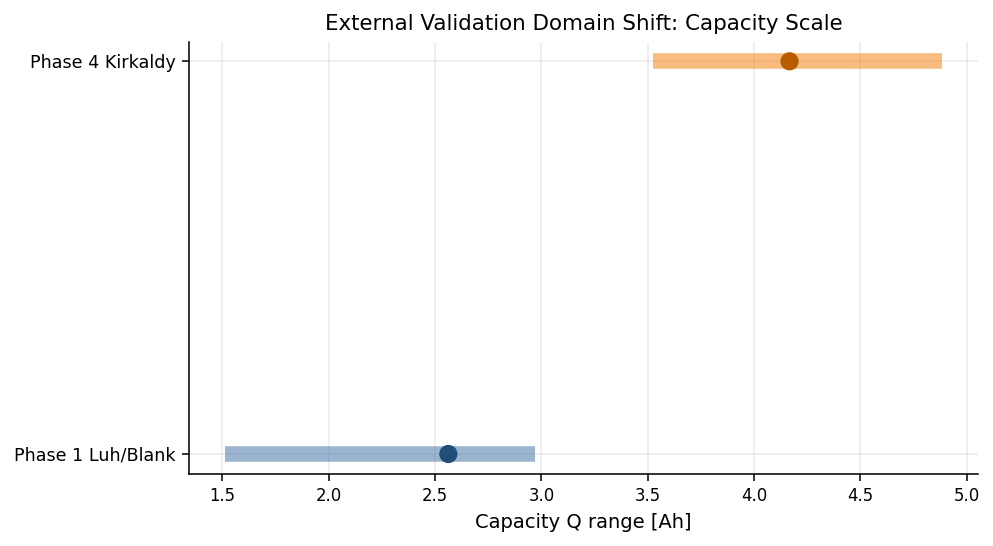

Saved: /kaggle/working/phase4_paper_ready_external_20260625_093834/figure_phase4_external_q_mape.png


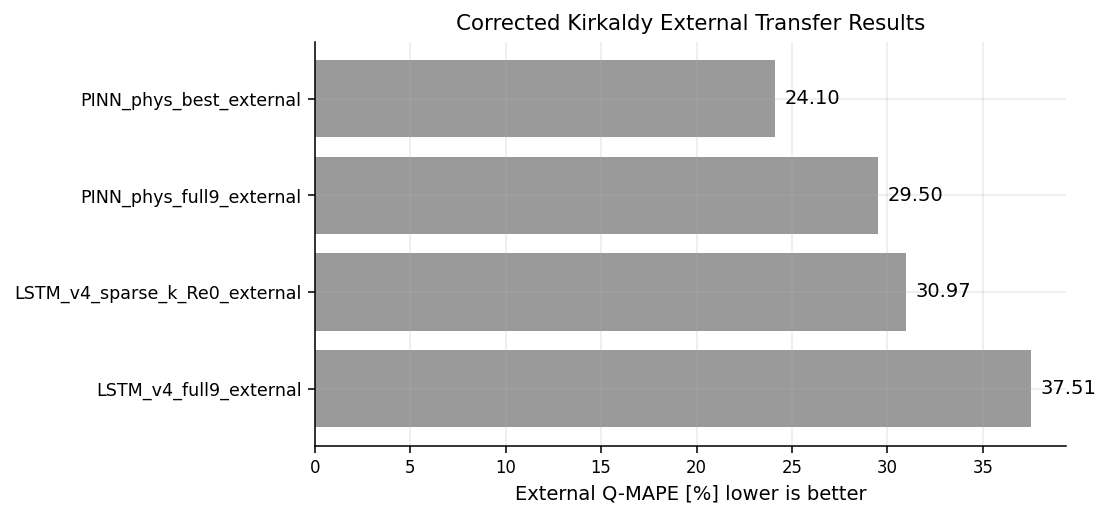

In [36]:
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def savefig(name):
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print("Saved:", path)


# Capacity scale/domain mismatch
fig, ax = plt.subplots(figsize=(7.2, 4.0))
labels = ["Phase 1 Luh/Blank", "Phase 4 Kirkaldy"]
mins = [luh_q["Q_min"], kirk_q["Q_min"]]
maxs = [luh_q["Q_max"], kirk_q["Q_max"]]
means = [luh_q["Q_mean"], kirk_q["Q_mean"]]
y = np.arange(len(labels))
ax.hlines(y, mins, maxs, linewidth=8, color=["#4C78A8", "#F58518"], alpha=0.55)
ax.scatter(means, y, color=["#1F4E79", "#B85C00"], s=70, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Capacity Q range [Ah]")
ax.set_title("External Validation Domain Shift: Capacity Scale")
ax.grid(axis="x", alpha=0.25)
savefig("figure_phase4_capacity_scale_mismatch.png")
plt.show()

# External Q-MAPE ranking
plot_metrics = external_metrics[external_metrics["Q_MAPE"].notna()].copy()
plot_metrics = plot_metrics.sort_values("Q_MAPE")
fig, ax = plt.subplots(figsize=(8.0, max(3.8, 0.48 * len(plot_metrics) + 1.5)))
colors = np.where(plot_metrics["source"].eq("computed_this_notebook"), "#4C78A8", "#9A9A9A")
ax.barh(plot_metrics["Model"], plot_metrics["Q_MAPE"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("External Q-MAPE [%] lower is better")
ax.set_title("Corrected Kirkaldy External Transfer Results")
for i, v in enumerate(plot_metrics["Q_MAPE"]):
    ax.text(v + 0.5, i, f"{v:.2f}", va="center")
ax.grid(axis="x", alpha=0.25)
savefig("figure_phase4_external_q_mape.png")
plt.show()

# External Q-R2 if computed
r2_plot = external_metrics[external_metrics["Q_R2"].notna()].copy()
if not r2_plot.empty:
    r2_plot = r2_plot.sort_values("Q_R2", ascending=False)
    fig, ax = plt.subplots(figsize=(7.0, 3.8))
    ax.barh(r2_plot["Model"], r2_plot["Q_R2"], color="#54A24B")
    ax.axvline(0, color="black", linewidth=1)
    ax.invert_yaxis()
    ax.set_xlabel("External Q-R2")
    ax.set_title("External R2 Under Domain Shift")
    ax.grid(axis="x", alpha=0.25)
    savefig("figure_phase4_external_q_r2.png")
    plt.show()

# Computed rollout trajectories
if not lstm_preds.empty:
    cells = list(lstm_preds["cell_key"].drop_duplicates())[:8]
    n = len(cells)
    fig, axes = plt.subplots(math.ceil(n / 2), 2, figsize=(10, max(4, 2.2 * math.ceil(n / 2))), squeeze=False)
    for ax, cell in zip(axes.ravel(), cells):
        g = lstm_preds[lstm_preds["cell_key"].eq(cell)].sort_values("k_exp")
        ax.plot(g["k_exp"], g["Q_true"], marker="o", label="true", color="#1F4E79")
        ax.plot(g["k_exp"], g["Q_pred"], marker="s", label="pred", color="#B85C00")
        ax.set_title(cell)
        ax.set_xlabel("k_exp")
        ax.set_ylabel("Q [Ah]")
        ax.grid(alpha=0.2)
    for ax in axes.ravel()[len(cells):]:
        ax.axis("off")
    axes.ravel()[0].legend(frameon=False)
    savefig("figure_phase4_lstm_rollout_trajectories.png")
    plt.show()


## 9. Export Manifest and Zip


In [37]:
manifest = {
    "run_tag": RUN_TAG,
    "kirkaldy_root": str(KIRK_ROOT),
    "performance_summary_csv_count": len(perf_csvs),
    "parsed_rows": int(len(phase4_features)),
    "parsed_cells": int(phase4_features["cell_key"].nunique()),
    "luh_q_stats": luh_q,
    "kirkaldy_q_stats": kirk_q,
    "lstm_artifact_status": lstm_artifact_status,
    "outputs": sorted([p.name for p in OUT_DIR.iterdir()]),
}
(OUT_DIR / "phase4_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

zip_path = WORKING / f"{RUN_TAG}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUT_DIR.rglob("*")):
        if p.is_file():
            z.write(p, arcname=p.relative_to(OUT_DIR))

print_section("Done")
print("Output directory:", OUT_DIR)
print("Zip:", zip_path)
print("Files:")
for p in sorted(OUT_DIR.iterdir()):
    print(" -", p.name)



Done
Output directory: /kaggle/working/phase4_paper_ready_external_20260625_093834
Zip: /kaggle/working/phase4_paper_ready_external_20260625_093834.zip
Files:
 - figure_phase4_capacity_scale_mismatch.png
 - figure_phase4_external_q_mape.png
 - phase4_claims_summary.md
 - phase4_dataset_diagnostics.csv
 - phase4_external_metrics_summary.csv
 - phase4_kirkaldy_phase1_like_features.csv
 - phase4_manifest.json
 - phase4_paper_claims_summary.csv
 - phase4_parse_errors.csv
